In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#membuat direktori train set dan validation set
import os
import numpy as np
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#melihat isi dari directory
import os
os.listdir('/content/drive/MyDrive/TA_DATASET')

['Blight', 'Blast', 'Tungro', 'BrownSpot']

In [ ]:
#melihat tau jumlah dari dataset
print('total Blight images    :', len(os.listdir('/content/drive/MyDrive/TA_DATASET/Blast')))
print('total Blast images     :', len(os.listdir('/content/drive/MyDrive/TA_DATASET/Blight')))
print('total BrownSpot images :', len(os.listdir('/content/drive/MyDrive/TA_DATASET/BrownSpot')))
print('total Tungro images    :', len(os.listdir('/content/drive/MyDrive/TA_DATASET/Tungro')))

total Blight images    : 1414
total Blast images     : 1344
total BrownSpot images : 1578
total Tungro images    : 490


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Path folder dataset asli
input_folder = '/content/drive/MyDrive/TA_DATASET'  # Ganti dengan path ke folder dataset utama

# Path output hasil splitting
output_folder = "dataset_split_9010"  # Folder hasil split

# Split dataset dengan rasio 90:10
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.9, 0.1), group_prefix=None)

print("Splitting dataset selesai!")

Copying files: 4826 files [02:33, 31.51 files/s]

Splitting dataset selesai!


In [ ]:
import shutil

# Path asal hasil split
source_folder = "/content/dataset_split_9010"

# Path tujuan di Google Drive
destination_folder = "/content/drive/MyDrive/TA_DATASET_SPLIT_9010"

# Copy seluruh folder ke Google Drive
shutil.move(source_folder, destination_folder)

print("Folder dataset_split berhasil disimpan ke Google Drive!")


Folder dataset_split berhasil disimpan ke Google Drive!


In [ ]:
#mengidentifikasikan train dir dan val dir
train_dir = os.path.join("/content/drive/MyDrive/TA_DATASET_SPLIT_9010/train")
validation_dir = os.path.join("/content/drive/MyDrive/TA_DATASET_SPLIT_9010/val")

In [ ]:
#membuat image data generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
batch_size=32
target_size = (150,150)

train_generator = train_datagen.flow_from_directory(
    train_dir, #direktori train
    batch_size=batch_size,
    target_size=target_size, #mengubah semua resolusi gambar menjadi 150x150
    class_mode='categorical')

val_generator = val_datagen.flow_from_directory(
    validation_dir, #direktori validation
    batch_size=batch_size,
    target_size=target_size, #mengubah semua resolusi gambar menjadi 150x150
    class_mode='categorical')

Found 4342 images belonging to 4 classes.
Found 484 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dropout, Flatten, Dense

# Input layer
input_layer = Input(shape=(150, 150, 3))

# Pre-trained Xception tanpa fully connected layer
hidden_layer_1 = Xception(weights='imagenet', include_top=False)(input_layer)
hidden_layer_2 = Flatten()(hidden_layer_1)
hidden_layer_3 = Dense(256, activation='relu')(hidden_layer_2)
hidden_layer_4 = Dropout(0.5)(hidden_layer_3)
output_layer = Dense(4, activation='softmax')(hidden_layer_4)

model_xception = Model(inputs=input_layer, outputs=output_layer)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_xception.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    13,107,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,969,964 (129.59 MB)

 Trainable params: 33,915,436 (129.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
model_xception.compile(loss='categorical_crossentropy', #karena lebih dari 2 kelas, menggunakan categorical_crossentropy
              optimizer=Adam(learning_rate=1e-04),
              metrics=['accuracy'])

In [ ]:
#callbacks
from tensorflow.keras.callbacks import Callback
class myCallback(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>1 and logs.get('val_accuracy')>1):
      print("\nAkurasi telah sampai lebih dari 100%!")
      self.model.stop_training = True
callbacks = myCallback()

In [ ]:
#fitting
model_xception.fit(train_generator,
          validation_data=val_generator,
          # steps_per_epoch=100,
          # callbacks=[callbacks],
          epochs=30)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.6424 - loss: 0.9846 - val_accuracy: 0.8822 - val_loss: 0.3012
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 123s 904ms/step - accuracy: 0.8909 - loss: 0.3039 - val_accuracy: 0.9277 - val_loss: 0.1968
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 118s 867ms/step - accuracy: 0.9122 - loss: 0.2347 - val_accuracy: 0.9298 - val_loss: 0.1954
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 117s 861ms/step - accuracy: 0.9241 - loss: 0.1945 - val_accuracy: 0.9525 - val_loss: 0.1287
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 119s 869ms/step - accuracy: 0.9405 - loss: 0.1737 - val_accuracy: 0.9545 - val_loss: 0.1088
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 119s 875ms/step - accuracy: 0.9341 - loss: 0.1752 - val_accuracy: 0.9545 - val_loss: 0.0966
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 118s 868ms/step - accuracy: 0.9476 - loss: 0.1426 - val_accuracy: 0.9298 - val_loss: 0.1839
Epoch 8/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 120s 882ms/step - accuracy: 0.9475 - lo

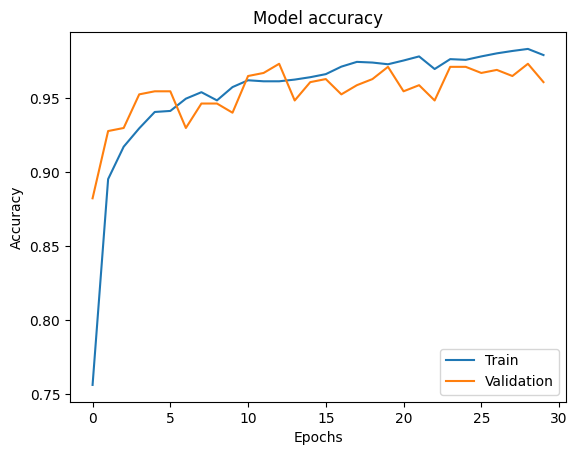

In [ ]:
#plot accuracy
import matplotlib.pyplot as plt
plt.plot(model_xception.history.history['accuracy'], label='Training Accuracy')
plt.plot(model_xception.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

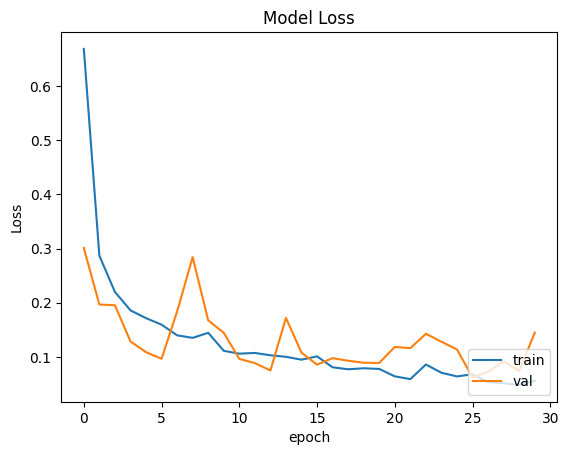

In [ ]:
#membuat plot loss
plt.plot(model_xception.history.history['loss'])
plt.plot(model_xception.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='lower right')
plt.show()

In [ ]:
model_xception.save('Model_XCEPTION9010.h5')
